# Tutorial: LightGBM CTR for MIND Ranking

Audience:
- This notebook is LightGBM CTR baseline.

Prerequisites:
- The MIND data is available under `data/train` and `data/valid`.
- `lightgbm`, `pandas`, `numpy`, `matplotlib`, and `scikit-learn` are available in the environment.

Learning goals:
- Understand what CTR prediction means in this ranking task.
- Build lightweight tabular features from impressions, user history, and news metadata.
- Train a LightGBM model to predict click probability.
- Evaluate the model with the same metrics required by the assignment: `AUC`, `MRR`, `nDCG@5`, and `nDCG@10`.
- Interpret the result with feature importance.


## What Is LightGBM CTR?

CTR stands for Click-Through Rate prediction. In this assignment, each impression already contains a candidate set of news articles, and our goal is to assign a score to each candidate so that clicked items rank above non-clicked items.

LightGBM is a gradient boosting tree model. It is a strong choice here because:
- it handles mixed numeric and categorical tabular features well,
- it can model nonlinear interactions better than plain Logistic Regression,
- it is usually fast enough for a baseline on MIND-scale tabular data,
- it gives interpretable feature importance after training.

In short, we will turn each `(impression, candidate_news)` pair into a feature vector, train a binary classifier on the click label, and use the predicted probability as the ranking score.


## Outline

1. Setup and data paths
2. Load the shared candidate tables and news metadata
3. Build features for LightGBM
4. Train the LightGBM CTR model
5. Generate validation predictions and evaluate ranking metrics
6. Inspect feature importance and summarize takeaways


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from lightgbm import LGBMClassifier, early_stopping, log_evaluation
except ImportError as exc:
    raise ImportError(
        "Please install lightgbm first, for example: pip install lightgbm"
    ) from exc

SEED = 42

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "outputs").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find project root from {start}. Expected a parent directory containing both 'data' and 'outputs'."
    )

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)

TRAIN_BEHAVIORS_PATH = PROJECT_ROOT / "data/train/behaviors.tsv"
VALID_BEHAVIORS_PATH = PROJECT_ROOT / "data/valid/behaviors.tsv"
TRAIN_NEWS_PATH = PROJECT_ROOT / "data/train/news.tsv"
VALID_NEWS_PATH = PROJECT_ROOT / "data/valid/news.tsv"
OUTPUT_DIR = NOTEBOOK_DIR / "lightgbm_ctr_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for path in [TRAIN_BEHAVIORS_PATH, VALID_BEHAVIORS_PATH, TRAIN_NEWS_PATH, VALID_NEWS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

print("Notebook directory:", NOTEBOOK_DIR.resolve())
print("Project root:", PROJECT_ROOT.resolve())
print("Seed:", SEED)
print("Output directory:", OUTPUT_DIR.resolve())


Notebook directory: /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines
Project root: /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit
Seed: 42
Output directory: /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/lightgbm_ctr_output


## Step 1 - Load The Data

We read the original `behaviors.tsv` files directly from `data/train` and `data/valid`, then expand each impression into candidate-level rows. Each row corresponds to one candidate news item inside one impression, which is exactly the granularity required for CTR ranking.

We also load `news.tsv` from train and validation so we can build content metadata features such as category, subcategory, and simple title length statistics.


In [2]:
NEWS_COLUMNS = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities",
]

BEHAVIORS_COLUMNS = ["impression_id", "user_id", "time", "history", "impressions"]

def parse_impressions(impressions: str):
    if not isinstance(impressions, str) or not impressions.strip():
        return []
    pairs = []
    for token in impressions.strip().split():
        if "-" not in token:
            continue
        news_id, label = token.rsplit("-", 1)
        try:
            y = int(label)
        except ValueError:
            continue
        pairs.append((news_id, y))
    return pairs

def expand_behaviors(path: Path) -> pd.DataFrame:
    behaviors = pd.read_csv(path, sep="\t", header=None, names=BEHAVIORS_COLUMNS, dtype=str)
    rows = []
    for _, row in behaviors.iterrows():
        pairs = parse_impressions(row["impressions"])
        for pos, (news_id, label) in enumerate(pairs):
            rows.append(
                {
                    "impression_id": row["impression_id"],
                    "user_id": row["user_id"],
                    "time": row["time"],
                    "history": row["history"] if isinstance(row["history"], str) else "",
                    "candidate_news_id": news_id,
                    "label": int(label),
                    "candidate_pos": pos,
                }
            )
    out = pd.DataFrame(rows)
    out["impression_id"] = out["impression_id"].astype(str)
    out["candidate_news_id"] = out["candidate_news_id"].astype(str)
    out["label"] = out["label"].astype(int)
    return out

train_candidates = expand_behaviors(TRAIN_BEHAVIORS_PATH)
valid_candidates = expand_behaviors(VALID_BEHAVIORS_PATH)

train_news = pd.read_csv(TRAIN_NEWS_PATH, sep="\t", header=None, names=NEWS_COLUMNS)
valid_news = pd.read_csv(VALID_NEWS_PATH, sep="\t", header=None, names=NEWS_COLUMNS)
news = pd.concat([train_news, valid_news], ignore_index=True).drop_duplicates("news_id")

print("Train candidates:", train_candidates.shape)
print("Valid candidates:", valid_candidates.shape)
print("Combined news table:", news.shape)
print("Train CTR:", round(train_candidates["label"].mean(), 4))
print("Valid CTR:", round(valid_candidates["label"].mean(), 4))

train_candidates.head()


Train candidates: (5843444, 7)
Valid candidates: (2740998, 7)
Combined news table: (65238, 8)
Train CTR: 0.0404
Valid CTR: 0.0406


,impression_id,user_id,time,history,candidate_news_id,label,candidate_pos
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689,1,0
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N35729,0,1
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678,0,0
3,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N39317,0,1
4,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N58114,0,2


## Step 2 - Feature Engineering

For a first-round baseline, we intentionally keep the features simple and interpretable.

The feature groups are:
- Impression features: candidate position, history length, unique history length, hour, weekday, weekend flag.
- Candidate news metadata: category, subcategory, title length, abstract length.
- Popularity statistics from training data: how often a news item appeared and was clicked.
- History matching features: how often the user's history matches the candidate's category and subcategory.

These are lightweight features, but they already capture several useful ranking signals: exposure order, user activity, content preference, and item popularity.


In [3]:
news = news.copy()
news["news_id"] = news["news_id"].astype(str)
news["category"] = news["category"].fillna("unknown").astype(str)
news["subcategory"] = news["subcategory"].fillna("unknown").astype(str)
news["title"] = news["title"].fillna("").astype(str)
news["abstract"] = news["abstract"].fillna("").astype(str)
news["title_word_count"] = news["title"].str.split().str.len().astype(np.int16)
news["abstract_word_count"] = news["abstract"].str.split().str.len().astype(np.int16)
news["title_char_count"] = news["title"].str.len().astype(np.int16)
news["abstract_char_count"] = news["abstract"].str.len().astype(np.int16)

news_features = news[[
    "news_id",
    "category",
    "subcategory",
    "title_word_count",
    "abstract_word_count",
    "title_char_count",
    "abstract_char_count",
]].copy()

def prepare_candidates(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["impression_id"] = df["impression_id"].astype(str)
    df["user_id"] = df["user_id"].fillna("unknown").astype(str)
    df["candidate_news_id"] = df["candidate_news_id"].astype(str)
    df["history"] = df["history"].fillna("").astype(str)
    df["label"] = df["label"].astype(np.int8)
    df["candidate_pos"] = df["candidate_pos"].astype(np.int16)
    return df

def build_impression_features(candidates: pd.DataFrame) -> pd.DataFrame:
    impressions = candidates[["impression_id", "time", "history"]].drop_duplicates("impression_id").copy()
    histories = impressions["history"].str.split()
    impressions["history_len"] = histories.str.len().fillna(0).astype(np.int16)
    impressions["history_unique_len"] = histories.apply(
        lambda x: len(set(x)) if isinstance(x, list) else 0
    ).astype(np.int16)
    timestamps = pd.to_datetime(impressions["time"], errors="coerce")
    impressions["hour"] = timestamps.dt.hour.fillna(-1).astype(np.int8)
    impressions["weekday"] = timestamps.dt.dayofweek.fillna(-1).astype(np.int8)
    impressions["is_weekend"] = impressions["weekday"].isin([5, 6]).astype(np.int8)
    return impressions

def build_history_match_tables(impression_features: pd.DataFrame, news_table: pd.DataFrame):
    exploded = impression_features[["impression_id", "history"]].copy()
    exploded["history_news_id"] = exploded["history"].str.split()
    exploded = exploded.explode("history_news_id").dropna(subset=["history_news_id"])
    if exploded.empty:
        empty_cat = pd.DataFrame(columns=["impression_id", "category", "history_category_count"])
        empty_subcat = pd.DataFrame(columns=["impression_id", "subcategory", "history_subcategory_count"])
        return empty_cat, empty_subcat
    history_news = exploded.merge(
        news_table[["news_id", "category", "subcategory"]],
        left_on="history_news_id",
        right_on="news_id",
        how="left",
    )
    history_news["category"] = history_news["category"].fillna("unknown")
    history_news["subcategory"] = history_news["subcategory"].fillna("unknown")
    category_counts = history_news.groupby(["impression_id", "category"]).size().reset_index(name="history_category_count")
    subcategory_counts = history_news.groupby(["impression_id", "subcategory"]).size().reset_index(name="history_subcategory_count")
    return category_counts, subcategory_counts

def build_popularity_features(train_df: pd.DataFrame) -> pd.DataFrame:
    popularity = (
        train_df.groupby("candidate_news_id")["label"]
        .agg(news_train_impressions="size", news_train_clicks="sum")
        .reset_index()
        .rename(columns={"candidate_news_id": "news_id"})
    )
    popularity["news_train_ctr"] = (
        popularity["news_train_clicks"] + 1.0
    ) / (popularity["news_train_impressions"] + 20.0)
    return popularity

def assemble_features(
    candidates: pd.DataFrame,
    impression_features: pd.DataFrame,
    news_table: pd.DataFrame,
    popularity_table: pd.DataFrame,
    category_counts: pd.DataFrame,
    subcategory_counts: pd.DataFrame,
) -> pd.DataFrame:
    df = candidates.merge(
        impression_features.drop(columns=["history"]),
        on="impression_id",
        how="left",
    )
    df = df.merge(news_table, left_on="candidate_news_id", right_on="news_id", how="left")
    df = df.merge(popularity_table, on="news_id", how="left")
    df = df.merge(category_counts, on=["impression_id", "category"], how="left")
    df = df.merge(subcategory_counts, on=["impression_id", "subcategory"], how="left")

    fill_map = {
        "category": "unknown",
        "subcategory": "unknown",
        "title_word_count": 0,
        "abstract_word_count": 0,
        "title_char_count": 0,
        "abstract_char_count": 0,
        "news_train_impressions": 0,
        "news_train_clicks": 0,
        "news_train_ctr": 0.0,
        "history_category_count": 0,
        "history_subcategory_count": 0,
    }
    df = df.fillna(fill_map)
    history_len_safe = df["history_len"].replace(0, 1)
    df["history_category_ratio"] = df["history_category_count"] / history_len_safe
    df["history_subcategory_ratio"] = df["history_subcategory_count"] / history_len_safe
    return df

train_candidates = prepare_candidates(train_candidates)
valid_candidates = prepare_candidates(valid_candidates)

train_impression_features = build_impression_features(train_candidates)
valid_impression_features = build_impression_features(valid_candidates)
train_category_counts, train_subcategory_counts = build_history_match_tables(train_impression_features, news_features)
valid_category_counts, valid_subcategory_counts = build_history_match_tables(valid_impression_features, news_features)
popularity_features = build_popularity_features(train_candidates)

train_df = assemble_features(
    train_candidates,
    train_impression_features,
    news_features,
    popularity_features,
    train_category_counts,
    train_subcategory_counts,
)
valid_df = assemble_features(
    valid_candidates,
    valid_impression_features,
    news_features,
    popularity_features,
    valid_category_counts,
    valid_subcategory_counts,
)

train_df[["candidate_news_id", "category", "subcategory", "news_train_ctr", "history_category_ratio"]].head()


,candidate_news_id,category,subcategory,news_train_ctr,history_category_ratio
0,N55689,sports,football_nfl,0.235451,0.222222
1,N35729,news,newsus,0.216803,0.333333
2,N20678,sports,more_sports,0.081791,0.036585
3,N39317,news,newspolitics,0.081395,0.658537
4,N58114,autos,autosnews,0.021073,0.000000


## Step 3 - Tune And Train A LightGBM CTR Model

Instead of fixing one parameter set by hand, we now use a simple coordinate-style search.

The idea is:
- start from a reasonable default parameter set,
- tune one hyperparameter at a time,
- keep the best value found on the validation AUC,
- carry that best setting into the next round.

This is cheaper than full grid search, but it is still much more systematic than manually guessing parameters.

We search over the following values:
- `num_leaves`: 31, 63, 127
- `min_child_samples`: 20, 50, 100
- `learning_rate`: 0.03, 0.05, 0.1
- `feature_fraction`: 0.7, 0.8, 0.9
- `bagging_fraction`: 0.7, 0.8, 0.9
- `max_depth`: 6, 8, -1

A useful detail here is that `category` and `subcategory` are treated as categorical features. This lets LightGBM split on them directly instead of forcing one-hot encoding by hand.


In [4]:
FEATURE_COLUMNS = [
    "candidate_pos",
    "history_len",
    "history_unique_len",
    "hour",
    "weekday",
    "is_weekend",
    "title_word_count",
    "abstract_word_count",
    "title_char_count",
    "abstract_char_count",
    "news_train_impressions",
    "news_train_clicks",
    "news_train_ctr",
    "history_category_count",
    "history_subcategory_count",
    "history_category_ratio",
    "history_subcategory_ratio",
    "category",
    "subcategory",
]

CATEGORICAL_COLUMNS = ["category", "subcategory"]

for col in CATEGORICAL_COLUMNS:
    train_df[col] = train_df[col].astype("category")
    valid_df[col] = valid_df[col].astype("category")

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df["label"].astype(np.int8)
X_valid = valid_df[FEATURE_COLUMNS]
y_valid = valid_df["label"].astype(np.int8)

search_space = {
    "num_leaves": [31, 63, 127],
    "min_child_samples": [20, 50, 100],
    "learning_rate": [0.03, 0.05, 0.1],
    "feature_fraction": [0.7, 0.8, 0.9],
    "bagging_fraction": [0.7, 0.8, 0.9],
    "max_depth": [6, 8, -1],
}

best_params = {
    "objective": "binary",
    "metric": "auc",
    "n_estimators": 400,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "max_depth": -1,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": SEED,
    "n_jobs": -1,
    "bagging_freq": 1,
    "verbosity": -1,
}

def train_and_score(params: dict, verbose_eval: bool = False):
    model = LGBMClassifier(**params)
    callbacks = [early_stopping(stopping_rounds=30, first_metric_only=True)]
    if verbose_eval:
        callbacks.append(log_evaluation(period=50))
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        categorical_feature=CATEGORICAL_COLUMNS,
        callbacks=callbacks,
    )
    best_auc = model.best_score_["valid_0"]["auc"]
    return model, float(best_auc)

search_records = []
current_model, current_best_auc = train_and_score(best_params, verbose_eval=False)
print("Initial AUC:", round(current_best_auc, 6))

for param_name, candidates in search_space.items():
    round_best_value = best_params[param_name]
    round_best_auc = current_best_auc
    print(f"\nTuning {param_name}...")
    for value in candidates:
        trial_params = best_params.copy()
        trial_params[param_name] = value
        trial_model, trial_auc = train_and_score(trial_params, verbose_eval=False)
        search_records.append(
            {
                "param_name": param_name,
                "trial_value": value,
                "valid_auc": trial_auc,
            }
        )
        print(f"  {param_name}={value} -> AUC={trial_auc:.6f}")
        if trial_auc > round_best_auc:
            round_best_auc = trial_auc
            round_best_value = value
            current_model = trial_model
    best_params[param_name] = round_best_value
    current_best_auc = round_best_auc
    print(f"Best {param_name}: {round_best_value}, AUC={round_best_auc:.6f}")

search_results = pd.DataFrame(search_records).sort_values(
    ["valid_auc", "param_name"], ascending=[False, True]
).reset_index(drop=True)

print("\nBest parameter set after coordinate search:")
print(json.dumps(best_params, indent=2))

model = LGBMClassifier(**best_params)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc",
    categorical_feature=CATEGORICAL_COLUMNS,
    callbacks=[
        early_stopping(stopping_rounds=30, first_metric_only=True),
        log_evaluation(period=50),
    ],
)

print("Final best iteration:", model.best_iteration_)
print("Final validation AUC:", model.best_score_["valid_0"]["auc"])
search_results.head(12)


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[4]	valid_0's auc: 0.627918
Evaluated only: auc
Initial AUC: 0.627918

Tuning num_leaves...
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[4]	valid_0's auc: 0.649855
Evaluated only: auc
  num_leaves=31 -> AUC=0.649855
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[4]	valid_0's auc: 0.627918
Evaluated only: auc
  num_leaves=63 -> AUC=0.627918
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[18]	valid_0's auc: 0.619714
Evaluated only: auc
  num_leaves=127 -> AUC=0.619714
Best num_leaves: 31, AUC=0.649855

Tuning min_child_samples...
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[4]	valid_0's auc: 0.649855
Evaluated only: auc
  min_child_samples=20 -> AUC=0.649855
Training until validation scores don

,param_name,trial_value,valid_auc
0,max_depth,6.00,0.655204
1,bagging_fraction,0.70,0.653754
2,max_depth,8.00,0.653754
3,max_depth,-1.00,0.653754
4,bagging_fraction,0.80,0.653425
5,feature_fraction,0.80,0.653425
6,learning_rate,0.10,0.653425
7,bagging_fraction,0.90,0.652600
8,feature_fraction,0.70,0.652407
9,feature_fraction,0.90,0.652394


## Step 4 - Evaluate The Ranking Result

The assignment asks for `AUC`, `MRR`, `nDCG@5`, and `nDCG@10`. Since ranking is defined inside each impression, we evaluate one impression at a time and then average the results.

The predicted click probability from LightGBM will be used directly as the ranking score.


In [5]:
def auc_binary(y_true: np.ndarray, y_score: np.ndarray):
    pos = np.sum(y_true == 1)
    neg = np.sum(y_true == 0)
    if pos == 0 or neg == 0:
        return None
    order = np.argsort(y_score)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(y_score) + 1)
    pos_ranks = ranks[y_true == 1].sum()
    return float((pos_ranks - pos * (pos + 1) / 2.0) / (pos * neg))

def mrr_binary(y_true: np.ndarray, y_score: np.ndarray):
    order = np.argsort(-y_score)
    sorted_y = y_true[order]
    pos_idx = np.where(sorted_y == 1)[0]
    if len(pos_idx) == 0:
        return 0.0
    return float(1.0 / (pos_idx[0] + 1))

def ndcg_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int):
    order = np.argsort(-y_score)[:k]
    gains = y_true[order].astype(float)
    discounts = 1.0 / np.log2(np.arange(2, len(gains) + 2))
    dcg = float(np.sum(gains * discounts))
    ideal = np.sort(y_true)[::-1][:k].astype(float)
    idcg = float(np.sum(ideal * discounts[: len(ideal)]))
    if idcg == 0:
        return 0.0
    return dcg / idcg

def evaluate_predictions(df: pd.DataFrame) -> dict:
    auc_list, mrr_list, ndcg5_list, ndcg10_list = [], [], [], []
    for _, g in df.groupby("impression_id", sort=False):
        y = g["label"].to_numpy(dtype=int)
        s = g["score"].to_numpy(dtype=float)
        auc_val = auc_binary(y, s)
        if auc_val is not None:
            auc_list.append(auc_val)
        mrr_list.append(mrr_binary(y, s))
        ndcg5_list.append(ndcg_at_k(y, s, 5))
        ndcg10_list.append(ndcg_at_k(y, s, 10))
    return {
        "impressions_total": int(df["impression_id"].nunique()),
        "impressions_with_auc": len(auc_list),
        "AUC": float(np.mean(auc_list)),
        "MRR": float(np.mean(mrr_list)),
        "nDCG@5": float(np.mean(ndcg5_list)),
        "nDCG@10": float(np.mean(ndcg10_list)),
    }

valid_scores = model.predict_proba(X_valid)[:, 1]
predictions = valid_df[["impression_id", "candidate_news_id", "label"]].copy()
predictions["score"] = valid_scores

metrics = evaluate_predictions(predictions)
metrics


{'impressions_total': 73152,
 'impressions_with_auc': 73152,
 'AUC': 0.6110283861834821,
 'MRR': 0.3332343321405803,
 'nDCG@5': 0.3141143150113706,
 'nDCG@10': 0.37155435453659136}

In [6]:
prediction_path = OUTPUT_DIR / "prediction.txt"
metrics_path = OUTPUT_DIR / "metrics.json"
importance_path = OUTPUT_DIR / "feature_importance.csv"
best_params_path = OUTPUT_DIR / "best_params.json"

predictions[["impression_id", "candidate_news_id", "score"]].to_csv(prediction_path, index=False)
with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
with best_params_path.open("w", encoding="utf-8") as f:
    json.dump(best_params, f, ensure_ascii=False, indent=2)

print("Saved prediction file to:", prediction_path)
print("Saved metrics file to:", metrics_path)


Saved prediction file to: /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/lightgbm_ctr_output/prediction.txt
Saved metrics file to: /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/lightgbm_ctr_output/metrics.json


## Step 5 - Interpret Feature Importance

One benefit of LightGBM is that it gives us an interpretable summary of which features matter most. This is helpful for the assignment because Member E is explicitly asked to provide feature importance.

In general, we expect popularity and history-matching features to be strong, because they directly reflect whether the candidate looks similar to what the user usually clicks.


In [7]:
importance_df = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "importance_gain": model.booster_.feature_importance(importance_type="gain"),
        "importance_split": model.booster_.feature_importance(importance_type="split"),
    }
).sort_values("importance_gain", ascending=False)

importance_df.to_csv(importance_path, index=False)
importance_df.head(10)


,feature,importance_gain,importance_split
12,news_train_ctr,319939.302979,25
0,candidate_pos,100822.638458,24
11,news_train_clicks,32956.648743,9
16,history_subcategory_ratio,26134.640106,10
14,history_subcategory_count,25385.739136,12
18,subcategory,15868.483093,22
15,history_category_ratio,11170.918823,9
10,news_train_impressions,2387.788971,4
3,hour,1403.313049,2
13,history_category_count,844.960022,1


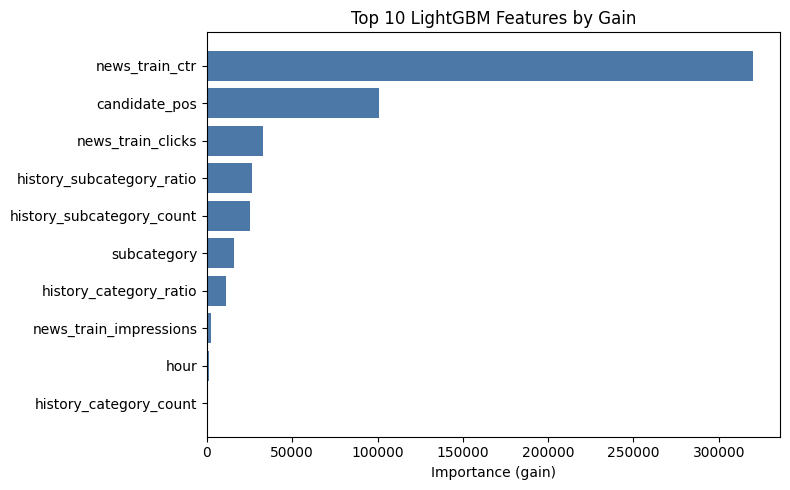

In [8]:
top_k = 10
plot_df = importance_df.head(top_k).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["importance_gain"], color="#4C78A8")
plt.title("Top 10 LightGBM Features by Gain")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.show()


## Common Pitfalls And Possible Extensions

Common pitfall:
- If the shared candidate files are missing, the notebook will fail before training. In that case, run the shared preprocessing step first to expand impressions into candidate-level rows.

Another pitfall:
- If `scale_pos_weight` is set too aggressively, validation ranking quality can become unstable even though the click labels are imbalanced.

Possible extensions:
- Add user-level historical CTR features.
- Add text embeddings from title or abstract instead of only length statistics.
- Tune LightGBM hyperparameters such as `num_leaves`, `min_child_samples`, and `learning_rate`.
- Compare this notebook directly with Member D's Logistic Regression CTR baseline.


## Possible Improvements

One simple next step is to test whether `history_len` should be treated as a bucketed user-activity feature instead of a raw numeric feature.

The intuition is that the exact difference between history length 42 and 43 may not matter much, but the difference between a very short-history user and a very long-history user may matter a lot.

In the following experiment, we:
- create a new categorical feature called `history_len_bucket`,
- retrain LightGBM with the same tuned hyperparameters,
- evaluate the updated model on the validation set,
- compare the new metrics against the baseline model.


In [9]:
train_df_improved = train_df.copy()
valid_df_improved = valid_df.copy()

bucket_labels = ["very_short", "short", "medium", "long", "very_long"]
bucket_bins = [-1, 5, 20, 50, 100, 1000]

train_df_improved["history_len_bucket"] = pd.cut(
    train_df_improved["history_len"],
    bins=bucket_bins,
    labels=bucket_labels,
)
valid_df_improved["history_len_bucket"] = pd.cut(
    valid_df_improved["history_len"],
    bins=bucket_bins,
    labels=bucket_labels,
)

train_df_improved["history_len_bucket"] = train_df_improved["history_len_bucket"].astype("category")
valid_df_improved["history_len_bucket"] = valid_df_improved["history_len_bucket"].astype("category")

IMPROVED_FEATURE_COLUMNS = FEATURE_COLUMNS + ["history_len_bucket"]
IMPROVED_CATEGORICAL_COLUMNS = CATEGORICAL_COLUMNS + ["history_len_bucket"]

X_train_improved = train_df_improved[IMPROVED_FEATURE_COLUMNS]
X_valid_improved = valid_df_improved[IMPROVED_FEATURE_COLUMNS]

improved_model = LGBMClassifier(**best_params)
improved_model.fit(
    X_train_improved,
    y_train,
    eval_set=[(X_valid_improved, y_valid)],
    eval_metric="auc",
    categorical_feature=IMPROVED_CATEGORICAL_COLUMNS,
    callbacks=[
        early_stopping(stopping_rounds=30, first_metric_only=True),
        log_evaluation(period=50),
    ],
)

improved_scores = improved_model.predict_proba(X_valid_improved)[:, 1]
improved_predictions = valid_df_improved[["impression_id", "candidate_news_id", "label"]].copy()
improved_predictions["score"] = improved_scores
improved_metrics = evaluate_predictions(improved_predictions)

comparison_df = pd.DataFrame(
    {
        "metric": ["AUC", "MRR", "nDCG@5", "nDCG@10"],
        "baseline": [metrics["AUC"], metrics["MRR"], metrics["nDCG@5"], metrics["nDCG@10"]],
        "improved": [
            improved_metrics["AUC"],
            improved_metrics["MRR"],
            improved_metrics["nDCG@5"],
            improved_metrics["nDCG@10"],
        ],
    }
)
comparison_df["delta"] = comparison_df["improved"] - comparison_df["baseline"]

print("Improved metrics:")
print(improved_metrics)
comparison_df


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 0.684566
Evaluated only: auc
Improved metrics:
{'impressions_total': 73152, 'impressions_with_auc': 73152, 'AUC': 0.6122429298150756, 'MRR': 0.33251117868556895, 'nDCG@5': 0.31547895575619983, 'nDCG@10': 0.3735240062791829}


,metric,baseline,improved,delta
0,AUC,0.611028,0.612243,0.001215
1,MRR,0.333234,0.332511,-0.000723
2,nDCG@5,0.314114,0.315479,0.001365
3,nDCG@10,0.371554,0.373524,0.001970
